In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.datasets import fetch_covtype
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
USING_KAGGLE = True
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
private_key = user_secrets.get_secret("private")
public_key = user_secrets.get_secret("public")
private_key = private_key[:35] + private_key[35:-33].replace(' ', '\n') + private_key[-33:] + '\n'
with open('key', 'w') as f:
    f.write(private_key)
with open('key.pub', 'w') as f:
    f.write(public_key)


In [4]:
!sudo chmod 600 /kaggle/working/key
!ssh-keyscan -t ecdsa github.com
!GIT_SSH_COMMAND='sudo ssh -i /kaggle/working/key -o IdentitiesOnly=yes -o StrictHostKeyChecking=no -o UserKnownHostsFile=/dev/null' git clone git@github.com:maximspbu/optimizers_comparison.git
!cd optimizers_comparison && git switch sprint5

# github.com:22 SSH-2.0-0264bb16
github.com ecdsa-sha2-nistp256 AAAAE2VjZHNhLXNoYTItbmlzdHAyNTYAAAAIbmlzdHAyNTYAAABBBEmKSENjQEezOmxkZMy7opKgwFB9nkt5YRrYMjNuG5N87uRgg6CLrbo5wAdT/y6v0mKV0U2w0WZ2YB/++Tpockg=
Cloning into 'optimizers_comparison'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 103 (delta 46), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 5.47 MiB | 21.15 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Branch 'sprint5' set up to track remote branch 'sprint5' from 'origin'.
Switched to a new branch 'sprint5'


In [5]:
%pip install lion_pytorch adabound torch-optimizer optax ray[tune] adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

In [ ]:
import time
import inspect
from typing import Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchmetrics.classification import MulticlassROC
from torchmetrics.classification import Accuracy, F1Score, MulticlassPrecision, MulticlassRecall, MulticlassConfusionMatrix
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2, ToTensor
from torchinfo import summary

import ray
from ray.train.torch import enable_reproducibility
from ray import tune
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler

from torch.optim import AdamW
from optimizers_comparison.src.optimizers import AdaBound
from torch_optimizer import Adahessian as AdaHessian
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

#notebook_dir = os.path.dirname(os.path.abspath("__file__"))

#project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

#if project_root not in sys.path:
#    sys.path.insert(0, project_root)

In [ ]:
from optimizers_comparison.src.config import setup, seed_worker, DEVICE, TORCH_GENERATOR
from optimizers_comparison.src.utils import create_writer, plot_results, plot_confusion_matrices_results, test_plot_roc_results
from optimizers_comparison.src.engine import train
from optimizers_comparison.src.model_builder import SimpleClassificationModel

E0000 00:00:1746965018.289904      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746965018.374838      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
setup(".")

2025-05-11 12:03:55,214	INFO worker.py:1852 -- Started a local Ray instance.
2025-05-11 12:03:55,294	INFO packaging.py:575 -- Creating a file package for local module '.'.
2025-05-11 12:03:55,378	INFO packaging.py:367 -- Pushing file package 'gcs://_ray_pkg_76cc58cee9eda416.zip' (12.10MiB) to Ray cluster...
2025-05-11 12:03:55,466	INFO packaging.py:380 -- Successfully pushed file package 'gcs://_ray_pkg_76cc58cee9eda416.zip'.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 20698964788.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 8870984908.0}


In [ ]:
def preprocess_data(filename: str) -> torch.Tensor:
    """Function to preprocess data

    Args:
        filename (str): Filename of data to be preprocessed.

    Returns:
        torch.Tensor: preprocessed data
    """
    data = pd.read_csv(filename)

    data_t = torch.Tensor(data.values)
    data_t = torch.nn.functional.normalize(data_t)

    return data_t


def get_train_valid_test_datasets(
    train_filename: str, test_filename: str
) -> Tuple[TensorDataset, ...]:
    train_df = pd.read_csv(train_filename)
    test_df = pd.read_csv(test_filename)

    X_train, X_valid, y_train, y_valid = train_test_split(
        train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values, random_state=0
    )

    X_train_np = X_train.astype(np.float32)
    y_train_np = y_train.astype(np.int64)
    X_valid_np = X_valid.astype(np.float32)
    y_valid_np = y_valid.astype(np.int64)

    X_test_np = test_df.iloc[:, :-1].values.astype(np.float32)
    y_test_np = test_df.iloc[:, -1].values.astype(np.int64)

    scaler = StandardScaler()
    X_train_scaled_np = scaler.fit_transform(X_train_np)
    X_valid_scaled_np = scaler.fit_transform(X_valid_np)
    X_test_scaled_np = scaler.transform(X_test_np)

    X_train_tensor = torch.tensor(X_train_scaled_np, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_np, dtype=torch.int64)
    X_valid_tensor = torch.tensor(X_valid_scaled_np, dtype=torch.float32)
    y_valid_tensor = torch.tensor(y_valid_np, dtype=torch.int64)
    X_test_tensor = torch.tensor(X_test_scaled_np, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.int64)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    return train_dataset, valid_dataset, test_dataset


In [10]:
# train_filename = (
#     "/kaggle/input/california-housing-prices/S7_california_housing_train.csv"
# )
# test_filename = "/kaggle/input/california-housing-prices/S7_california_housing_test.csv"
df = pd.DataFrame(fetch_covtype(random_state=0, as_frame=True, shuffle=True)['frame'])
df['Cover_Type'] = df['Cover_Type'] - 1
num_classes = 7
train_filename = "optimizers_comparison/data/covtype_train.csv"
test_filename = "optimizers_comparison/data/covtype_test.csv"
df = df[:int(len(df)*0.1)]  # dataset is too large
df[:int(len(df)*0.9)].to_csv(train_filename, index=False)
df[int(len(df)*0.9):].to_csv(test_filename, index=False)
train_dataset, valid_dataset, test_dataset = get_train_valid_test_datasets(
    train_filename=train_filename, test_filename=test_filename
)

In [ ]:
INPUT_SHAPE = 54
HIDDEN_UNITS = 54
OUTPUT_SHAPE = num_classes
summary(SimpleClassificationModel(input_shape=INPUT_SHAPE, hidden_units=HIDDEN_UNITS, output_shape=OUTPUT_SHAPE,))

Layer (type:depth-idx)                   Param #
SimpleClassificationModel                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       2,970
│    └─Identity: 2-2                     --
│    └─Identity: 2-3                     --
│    └─Identity: 2-4                     --
│    └─Linear: 2-5                       385
Total params: 3,355
Trainable params: 3,355
Non-trainable params: 0

In [ ]:
OPTIMIZERS_PARAMS: dict = {
    AdaHessian: {
        "lr": tune.grid_search([1e-2, 1e-1, 0.15, 1.0]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "hessian_power": tune.grid_search([0.5, 0.75, 1.0]),
        "seed": tune.grid_search([0]),
    },
    Lion: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "decoupled_weight_decay": tune.grid_search([False, True]),
        "use_triton": tune.grid_search([False]),
    },
    AdaBelief: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
        "weight_decouple": tune.grid_search([False, True]),
        "rectify": tune.grid_search([False, True]),
        "print_change_log": tune.grid_search([False]),
    },
    AdamW: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
    },
    AdaBound: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "final_lr": tune.grid_search([1e-3, 1e-2, 1e-1]),
        "gamma": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3]),
        "amsbound": tune.grid_search([False, True]),
    },
}

NUM_EPOCHS = 26
EPOCH_STEP = 5
BATCH_SIZE = 256

writer = create_writer(
    experiment_name="classification",
    model_name="simple_reg_model",
)

cls_analysis_optimizer = {}
classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),}

reporter = JupyterNotebookReporter(
    metric_columns=["test_loss"], mode="min", print_intermediate_tables=False
)

train_dataset_ref = ray.put(train_dataset)
valid_dataset_ref = ray.put(valid_dataset)
test_dataset_ref = ray.put(test_dataset)


for metric in classification_metrics:
    reporter.add_metric_column(f"valid_{metric}")

for optimizer_type in OPTIMIZERS_PARAMS.keys():

    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.

        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        enable_reproducibility()
        train_dataloader = DataLoader(
            dataset=ray.get(train_dataset_ref),
            batch_size=BATCH_SIZE,
            pin_memory=True,
            num_workers=2,
            shuffle=True,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        valid_dataloader = DataLoader(
            dataset=ray.get(valid_dataset_ref),
            batch_size=BATCH_SIZE,
            num_workers=2,
            pin_memory=True,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        test_dataloader = DataLoader(
            dataset=ray.get(test_dataset_ref),
            batch_size=BATCH_SIZE,
            num_workers=2,
            pin_memory=True,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=TORCH_GENERATOR,
        )
        model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(DEVICE)
        loss_fn = torch.nn.CrossEntropyLoss()
        optimizer = optimizer_type(
            model.parameters(),
            **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]},
        )
        # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        #     optimizer, mode="min", patience=5, factor=0.5, verbose=True
        # )
        d = train(
            model=model,
            train_dataloader=train_dataloader,
            valid_dataloader=valid_dataloader,
            test_dataloader=test_dataloader,
            loss_fn=loss_fn,
            metrics=classification_metrics,
            optimizer=optimizer,
            epochs=NUM_EPOCHS,
            device=DEVICE,
            # scheduler=scheduler,
            epoch_step=EPOCH_STEP,
        )
        tune.report(
            {"test_loss": d["test_loss"][0]}
            | {f"test_{str(i)}": d[f"test_{str(i)}"][0] for i in classification_metrics}
        )

    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in OPTIMIZERS_PARAMS[optimizer_type].items()},
        scheduler=ASHAScheduler(metric="test_f1score", mode="max"),
        progress_reporter=reporter,
        resources_per_trial={
            "cpu": 2,
            "gpu": 1,
        },
        log_to_file=True,
    )
    cls_analysis_optimizer[optimizer_type] = analysis


2025-05-11 12:05:06,560	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=527) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=527) E0000 00:00:1746965132.532914     527 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=527) E0000 00:00:1746965132.541183     527 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=527) /usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creatin

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_2da32_00000,0.740664,0.740664,0.619507,0.660942,0.502067
wrap_2da32_00001,0.752194,0.752194,0.590991,0.689175,0.536371
wrap_2da32_00002,0.755808,0.755808,0.559755,0.674139,0.549169
wrap_2da32_00003,0.778524,0.778524,0.514305,0.718477,0.564371
wrap_2da32_00004,0.786267,0.786267,0.50432,0.736589,0.589728
wrap_2da32_00005,0.787988,0.787988,0.502654,0.740503,0.614771
wrap_2da32_00006,0.791774,0.791774,0.510462,0.776813,0.59859
wrap_2da32_00007,0.78816,0.78816,0.499405,0.749377,0.596958
wrap_2da32_00008,0.786095,0.786095,0.50303,0.719254,0.623038
wrap_2da32_00009,0.773877,0.773877,0.521473,0.619776,0.511725


(pid=1738) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=1738) E0000 00:00:1746965202.252731    1738 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=1738) E0000 00:00:1746965202.260469    1738 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(wrap pid=528) /usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
(wrap 

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_299c6_00000,0.746343,0.746343,0.599231,0.652334,0.531215
wrap_299c6_00001,0.742901,0.742901,0.611169,0.645192,0.513592
wrap_299c6_00002,0.78816,0.78816,0.496024,0.718386,0.598643
wrap_299c6_00003,0.786095,0.786095,0.493695,0.733989,0.610326
wrap_299c6_00004,0.674927,0.674927,2.06932,0.428066,0.388259
wrap_299c6_00005,0.718293,0.718293,0.966046,0.587379,0.432975
wrap_299c6_00006,0.488384,0.488384,275.726,0.187676,0.146768
wrap_299c6_00007,0.490105,0.490105,61.1186,0.212561,0.157295
wrap_299c6_00008,0.747032,0.747032,0.599195,0.652694,0.530734
wrap_299c6_00009,0.661332,0.661332,0.831403,0.419086,0.327364


(pid=31423) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(pid=31423) E0000 00:00:1746966884.972272   31423 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=31423) E0000 00:00:1746966884.980524   31423 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(pid=32634) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=32634) E0000 00:00:1746966942.246168   32634 cuda_dnn.cc:8310] Unable to register cuDNN fac

...

2025-05-11 13:48:08,215	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/wrap_2025-05-11_12-45-05' in 0.0968s.
2025-05-11 13:48:08,264	INFO tune.py:1041 -- Total run time: 3783.04 seconds (3782.87 seconds for the tuning loop).
2025-05-11 13:48:08,424	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(pid=123100) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=123100) E0000 00:00:1746971297.406750  123100 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=123100) E0000 00:00:1746971297.414127  123100 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to 

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_92517_00000,0.722595,0.722595,0.670696,0.456096,0.423914
wrap_92517_00001,0.720874,0.720874,0.68127,0.454844,0.421055
wrap_92517_00002,0.763208,0.763208,0.542705,0.694434,0.564234
wrap_92517_00003,0.762175,0.762175,0.545627,0.678776,0.554501
wrap_92517_00004,0.782481,0.782481,0.511603,0.757446,0.623809
wrap_92517_00005,0.781105,0.781105,0.512477,0.767465,0.625574
wrap_92517_00006,0.703321,0.703321,0.68446,0.556204,0.428387
wrap_92517_00007,0.71227,0.71227,0.661138,0.663099,0.45318
wrap_92517_00008,0.722595,0.722595,0.670696,0.456096,0.423914
wrap_92517_00009,0.720874,0.720874,0.68127,0.454844,0.421055


(pid=124345) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=124345) E0000 00:00:1746971356.226547  124345 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=123098) E0000 00:00:1746971297.425751  123098 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=124345) E0000 00:00:1746971356.241758  124345 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=125553) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=125553) E0000 00:00:1746971413.464150  125553 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugi

Trial name,test_accuracy,test_f1score,test_loss,test_precision,test_recall
wrap_c3866_00000,0.701428,0.701428,0.729279,0.434122,0.393781
wrap_c3866_00001,0.69988,0.69988,0.732176,0.433201,0.392621
wrap_c3866_00002,0.721735,0.721735,0.672219,0.456223,0.422451
wrap_c3866_00003,0.720874,0.720874,0.68195,0.456173,0.421331
wrap_c3866_00004,0.728274,0.728274,0.647923,0.600575,0.430008
wrap_c3866_00005,0.728618,0.728618,0.649161,0.598867,0.429018
wrap_c3866_00006,0.656169,0.656169,0.892943,0.275421,0.315737
wrap_c3866_00007,0.656514,0.656514,0.893634,0.275645,0.316165
wrap_c3866_00008,0.721907,0.721907,0.680554,0.459352,0.422669
wrap_c3866_00009,0.721735,0.721735,0.68461,0.461457,0.421853


(pid=144049) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=144049) E0000 00:00:1746972299.156619  144049 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=144049) E0000 00:00:1746972299.164557  144049 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered [repeated 2x across cluster]
(pid=145260) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR [repeated 2x across cluster]
(pid=145260) E0000 00:00:1746972358.712846  145260 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered [repeated 2x across cluster]
(pid=145260) E0000 00:00:1746972358.720204  145260 cuda_blas.cc:1418] Unable to register

In [13]:
optimizer_comparison_acc_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_accuracy", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "Accuracy": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result[f"test_accuracy"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_accuracy", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_acc_df

,Optimizer,Config,Accuracy,Time_total_s
0,Adahessian,"{'lr': 0.15, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': 0}",0.791774,56.416034
1,Lion,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",0.797109,43.788289
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.787644,46.663862
3,AdamW,"{'lr': 0.01, 'weight_decay': 0.0001, 'amsgrad': True}",0.786612,45.097362
4,AdaBound,"{'lr': 0.01, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}",0.789881,47.705300


In [14]:
optimizer_comparison_f1_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                        "Config": [i.get_best_config(metric=f"test_f1score", mode="max") for i in cls_analysis_optimizer.values()], 
                                        "F1Score": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result[f"test_f1score"] for i in cls_analysis_optimizer.values()], 
                                        "Time_total_s": [i.get_best_trial(metric=f"test_f1score", mode="max").last_result['time_total_s'] for i in cls_analysis_optimizer.values()],
                                       })

optimizer_comparison_f1_df

,Optimizer,Config,F1Score,Time_total_s
0,Adahessian,"{'lr': 0.15, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': 0}",0.791774,56.416034
1,Lion,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}",0.797109,43.788289
2,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}",0.787644,46.663862
3,AdamW,"{'lr': 0.01, 'weight_decay': 0.0001, 'amsgrad': True}",0.786612,45.097362
4,AdaBound,"{'lr': 0.01, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}",0.789881,47.705300


**Анализ по оптимизаторам:**

1.  **Adahessian**
    *   Accuracy/F1: 0.7918
    *   Конфигурация: LR 0.15, WD 0.
    *   Анализ: Показатель производительности 0.7918 (Accuracy/F1) является вторым среди рассмотренных. Время обучения Adahessian составило 56.4s, что является наибольшим значением. Отмечено отсутствие регуляризации в конфигурации, показавшей указанный результат.
    *   Итог: Точность 0.7918, время обучения 56.4s (наибольшее).

2.  **Lion**
    *   Accuracy/F1: 0.7971 (Наивысший результат)
    *   Конфигурация: LR 0.001, WD 0.001.
    *   Анализ: Lion продемонстрировал наивысшие значения производительности по обеим метрикам. Время обучения составило 43.8s, что является наименьшим значением. Оптимальная конфигурация использует LR 0.001 и регуляризацию (WD=0.001).
    *   Итог: Наивысшая точность/F1 (0.7971) и наименьшее время обучения (43.8s).

3.  **AdaBelief**
    *   Accuracy/F1: 0.7876
    *   Конфигурация: LR 0.01, WD 0.001, `amsgrad` и `weight_decouple` учтены.
    *   Анализ: Значения метрик (0.7876) ниже, чем у Lion и Adahessian. Время обучения составило 46.7s.
    *   Итог: Точность/F1 0.7876, время обучения 46.7s.

4.  **AdamW**
    *   Accuracy/F1: 0.7866 (Наименьший результат)
    *   Конфигурация: LR 0.01, WD 0.0001, `amsgrad` учтены.
    *   Анализ: Показал наименьшие значения метрик качества (0.7866) среди рассмотренных оптимизаторов; разница со значениями AdaBelief и AdaBound составляет менее 0.004. Время обучения составило 45.1s, что является вторым наименьшим значением.
    *   Итог: Наименьшая точность/F1 (0.7866), время обучения 45.1s.

5.  **AdaBound**
    *   Accuracy/F1: 0.7899
    *   Конфигурация: LR 0.01, WD 0.0001. `final_lr` (0.1) выше начального `lr`.
    *   Анализ: Значение метрик (0.7899) выше, чем у AdamW и AdaBelief, и ниже, чем у Adahessian и Lion. Время обучения составило 47.7s.
    *   Итог: Точность/F1 0.7899, время обучения 47.7s.

**Общие выводы по Covertype Dataset (Классификация):**

1.  **Сравнение производительности:** Оптимизатор Lion показал наивысшие значения точности/F1 и наименьшее время обучения.
2.  **Совпадение метрик:** Для всех оптимизаторов конфигурации, давшие наилучшие результаты по Accuracy, также дали наилучшие результаты по F1 Score, при этом значения метрик совпали. Это может быть связано с использованием F1 Score с усреднением "micro" (численно равного Accuracy) или особенностями задачи, при которых улучшение одной метрики коррелирует с улучшением другой.
3.  **Диапазон точности:** Разница в точности между оптимизатором с наивысшим показателем (Lion, 0.7971) и оптимизатором с наименьшим (AdamW, 0.7866) составляет приблизительно 0.0105 (около 1.05%).
4.  **Время обучения:** Разница во времени обучения более существенна: Lion (43.8s, наименьшее время) и Adahessian (56.4s, наибольшее время). AdamW (45.1s) также показал относительно малое время обучения.

**Заключение:** Для задачи классификации на датасете Covertype, с учетом использованной модели и диапазона гиперпараметров, оптимизатор Lion показал сочетание наивысшей точности и наименьшего времени обучения. AdamW может рассматриваться при приоритете скорости выполнения и допустимости некоторого снижения точности. Adahessian, показав второй результат по точности, характеризовался наибольшим временем обучения.

In [15]:
results = {}
TEST_NUM_EPOCHS = 51
TEST_EPOCH_STEP = 1

train_dataloader = DataLoader(
    dataset=ray.get(train_dataset_ref),
    batch_size=BATCH_SIZE,
    pin_memory=True,
    num_workers=2,
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
valid_dataloader = DataLoader(
    dataset=ray.get(valid_dataset_ref),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)
test_dataloader = DataLoader(
    dataset=ray.get(test_dataset_ref),
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True,
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=TORCH_GENERATOR,
)

classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),
                          "confusion_matrix": MulticlassConfusionMatrix(num_classes=num_classes),
                          "multiclass_roc": MulticlassROC(num_classes=num_classes)
                          }

for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_f1_df["Config"]):
    model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_type(model.parameters(), **{i: config[i] for i in config if i in OPTIMIZERS_PARAMS[optimizer_type]})
    start = time.perf_counter()
    d = train(
             model=model,
             train_dataloader=train_dataloader,
             valid_dataloader=valid_dataloader,
             test_dataloader=test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=TEST_NUM_EPOCHS,
             device=DEVICE,
             #scheduler=scheduler,
             epoch_step=TEST_EPOCH_STEP,
         )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    results[optimizer_name] = d

/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:825: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at ../torch/csrc/autograd/engine.cpp:1201.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adahessian was trained for 84.65083070999935 seconds
Lion was trained for 71.43360319500061 seconds
Weight decoupling enabled in AdaBelief
AMSGrad enabled in AdaBelief
AdaBelief was trained for 72.7569022789994 seconds
AdamW was trained for 71.48103387000083 seconds
AdaBound was trained for 74.9651523499997 seconds


In [16]:
default_results = {}

classification_metrics = {"accuracy": Accuracy("multiclass", num_classes=num_classes), 
                          "f1score": F1Score("multiclass", num_classes=num_classes),
                          "precision": MulticlassPrecision(num_classes=num_classes),
                          "recall": MulticlassRecall(num_classes=num_classes),
                          "confusion_matrix": MulticlassConfusionMatrix(num_classes=num_classes),
                          "multiclass_roc": MulticlassROC(num_classes=num_classes)
                          }

for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_f1_df["Config"]):
    model = SimpleClassificationModel(input_shape=INPUT_SHAPE, 
                                      hidden_units=HIDDEN_UNITS, 
                                      output_shape=num_classes, 
                                      activation_function=nn.ReLU(),
                                     ).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = optimizer_type(model.parameters())
    start = time.perf_counter()
    d = train(
             model=model,
             train_dataloader=train_dataloader,
             valid_dataloader=valid_dataloader,
             test_dataloader=test_dataloader,
             loss_fn=loss_fn,
             metrics=classification_metrics,
             optimizer=optimizer,
             epochs=TEST_NUM_EPOCHS,
             device=DEVICE,
             #scheduler=scheduler,
             epoch_step=TEST_EPOCH_STEP,
         )
    end = time.perf_counter()
    time_training = end - start
    d['time_training'] = [time_training]
    optimizer_name = "default_" + str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
    print(f"{optimizer_name} was trained for {time_training} seconds")
    default_results[optimizer_name] = d


default_Adahessian was trained for 86.50041417799912 seconds
default_Lion was trained for 73.31688241600023 seconds
Please check your arguments if you have upgraded adabelief-pytorch from version 0.0.5.
Modifications to default arguments:
                           eps  weight_decouple    rectify
-----------------------  -----  -----------------  ---------
adabelief-pytorch=0.0.5  1e-08  False              False
>=0.1.0 (Current 0.2.0)  1e-16  True               True
SGD better than Adam (e.g. CNN for Image Classification)    Adam better than SGD (e.g. Transformer, GAN)
----------------------------------------------------------  ----------------------------------------------
Recommended eps = 1e-8                                      Recommended eps = 1e-16
For a complete table of recommended hyperparameters, see
https://github.com/juntang-zhuang/Adabelief-Optimizer
You can disable the log message by setting "print_change_log = False", though it is recommended to keep as a reminder.

W

In [17]:
results_df = (
    pd.DataFrame(results)
    .T[["test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1score", "time_training"]]
    .map(lambda x: x[0])
)

results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_f1_df['Config']).set_index(results_df.index)], axis=1)

default_results_df = (
    pd.DataFrame(default_results)
    .T[["test_loss", "test_accuracy", "test_precision", "test_recall", "test_f1score", "time_training"]]
    .map(lambda x: x[0])
)
default_results_df['Config'] = [{i: j for i, j in zip(inspect.getfullargspec(optimizer.__init__).args[2:], inspect.getfullargspec(optimizer.__init__).defaults)} for optimizer in OPTIMIZERS_PARAMS]

pd.concat([results_df, default_results_df])

,test_loss,test_accuracy,test_precision,test_recall,test_f1score,time_training,Config
Adahessian,0.485677,0.801411,0.773537,0.635708,0.801411,84.650831,"{'lr': 0.15, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': 0}"
Lion,0.484199,0.803132,0.737551,0.664558,0.803132,71.433603,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False}"
AdaBelief,0.474782,0.807262,0.741141,0.674508,0.807262,72.756902,"{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': True, 'weight_decouple': True, 'rectify': False, 'print_change_log': False}"
AdamW,0.482932,0.798141,0.740561,0.681507,0.798141,71.481034,"{'lr': 0.01, 'weight_decay': 0.0001, 'amsgrad': True}"
AdaBound,0.493671,0.794528,0.711541,0.647623,0.794528,74.965152,"{'lr': 0.01, 'final_lr': 0.1, 'gamma': 0.0001, 'weight_decay': 0.0001, 'amsbound': False}"
default_Adahessian,0.486989,0.799002,0.732663,0.672456,0.799002,86.500414,"{'lr': 0.15, 'betas': (0.9, 0.999), 'eps': 0.0001, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': None}"
default_Lion,0.546603,0.768026,0.660404,0.559131,0.768026,73.316882,"{'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}"
default_AdaBelief,0.525429,0.775426,0.742928,0.592214,0.775426,75.781430,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-16, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'fixed_decay': False, 'rectify': True, 'degenerated_to_sgd': True, 'print_change_log': True}"
default_AdamW,0.515771,0.780589,0.701363,0.584091,0.780589,73.586392,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False}"
default_AdaBound,0.526997,0.778524,0.688972,0.591136,0.778524,75.209141,"{'lr': 0.001, 'betas': (0.9, 0.999), 'final_lr': 0.1, 'gamma': 0.001, 'eps': 1e-08, 'weight_decay': 0, 'amsbound': False}"


**Анализ результатов:**

1.  **Сравнение производительности конфигураций с подобранными и стандартными параметрами:**
    *   В данной задаче классификации конфигурации с **настроенными** параметрами показывают преимущество над конфигурациями со **стандартными (исходными)** параметрами для большинства оптимизаторов при оценке на тестовых данных.
    *   **Adahessian:** Конфигурация с **настроенными** параметрами демонстрирует незначительное улучшение по метрикам и времени выполнения по сравнению с **исходной**.
    *   **Lion:** Конфигурация с **настроенными** параметрами превосходит **исходную** по метрикам Accuracy/F1 на приблизительно 3.5%. Конфигурация с **настроенными** параметрами также имеет меньшее время выполнения.
    *   **AdaBelief:** Конфигурация с **настроенными** параметрами показывает улучшение по метрикам качества на приблизительно 3.2% и незначительное уменьшение времени выполнения по сравнению с **исходной**.
    *   **AdamW:** Конфигурация с **настроенными** параметрами демонстрирует улучшение по метрикам на приблизительно 1.75% и незначительное уменьшение времени выполнения по сравнению с **исходной**.
    *   **AdaBound:** Конфигурация с **настроенными** параметрами показывает улучшение по метрикам на приблизительно 1.6% и незначительное уменьшение времени выполнения по сравнению с **исходной**.

    **Вывод по сравнению конфигураций с настроенными и стандартными параметрами:** Для задачи классификации на датасете Covertype подбор гиперпараметров привел к улучшению качества моделей на тестовых данных для всех рассмотренных оптимизаторов. Наибольшее улучшение наблюдалось для оптимизаторов Lion, AdaBelief, AdamW и AdaBound, чьи **стандартные** настройки показали менее высокие результаты.

2.  **Выбор оптимизатора (на основе тестовых данных):**
    *   **Метрики качества (Accuracy/F1/Loss):** **AdaBelief (с настроенными параметрами)** показывает наивысшие значения Accuracy/F1 (0.8073) и наименьшее значение Loss (0.4748). За ним следует Lion (с настроенными параметрами) с Accuracy/F1 0.8031. Adahessian (с настроенными параметрами) и AdamW (с настроенными параметрами) демонстрируют несколько более низкие значения.
    *   **Время выполнения:** Наименьшее время выполнения показывают **Lion (с настроенными параметрами)** (71.43s) и **AdamW (с настроенными параметрами)** (71.48s). **AdaBelief (с настроенными параметрами)** (72.76s) имеет близкое к ним время выполнения. AdaBound (с настроенными параметрами) имеет большее время выполнения, а Adahessian (как с настроенными, так и со стандартными параметрами) — наибольшее (84-86s).

    *   **Сбалансированный выбор:** **AdaBelief (с настроенными параметрами)** демонстрирует сочетание высоких показателей качества и времени выполнения, близкого к наименьшим значениям. **Lion (с настроенными параметрами)** может рассматриваться при приоритете наименьшего времени выполнения и допустимости снижения точности на ~0.4% по сравнению с AdaBelief (с настроенными параметрами). AdamW (с настроенными параметрами) также имеет малое время выполнения, но уступает по точности AdaBelief (с настроенными параметрами) и Lion (с настроенными параметрами).

**Итоговые выводы:**

1.  **Оптимизатор для задачи:** На основе тестовых данных для задачи классификации Covertype, **AdaBelief** с **подобранными** параметрами (`{'lr': 0.01, 'weight_decay': 0.001, 'amsgrad': True, ...}`) показывает наивысшие значения точности и F1-меры при времени обучения, близком к минимальному. Lion (с **подобранными** параметрами) является альтернативой с наименьшим временем обучения и незначительно меньшей точностью.
2.  **Целесообразность подбора гиперпараметров:** Для данной задачи подбор гиперпараметров привел к улучшению качества моделей на тестовых данных по сравнению с использованием **параметров по умолчанию** для большинства оптимизаторов. Это указывает на значимость настройки гиперпараметров для достижения более высоких показателей производительности, особенно когда **стандартные** настройки не являются оптимальными для конкретной задачи или модели.

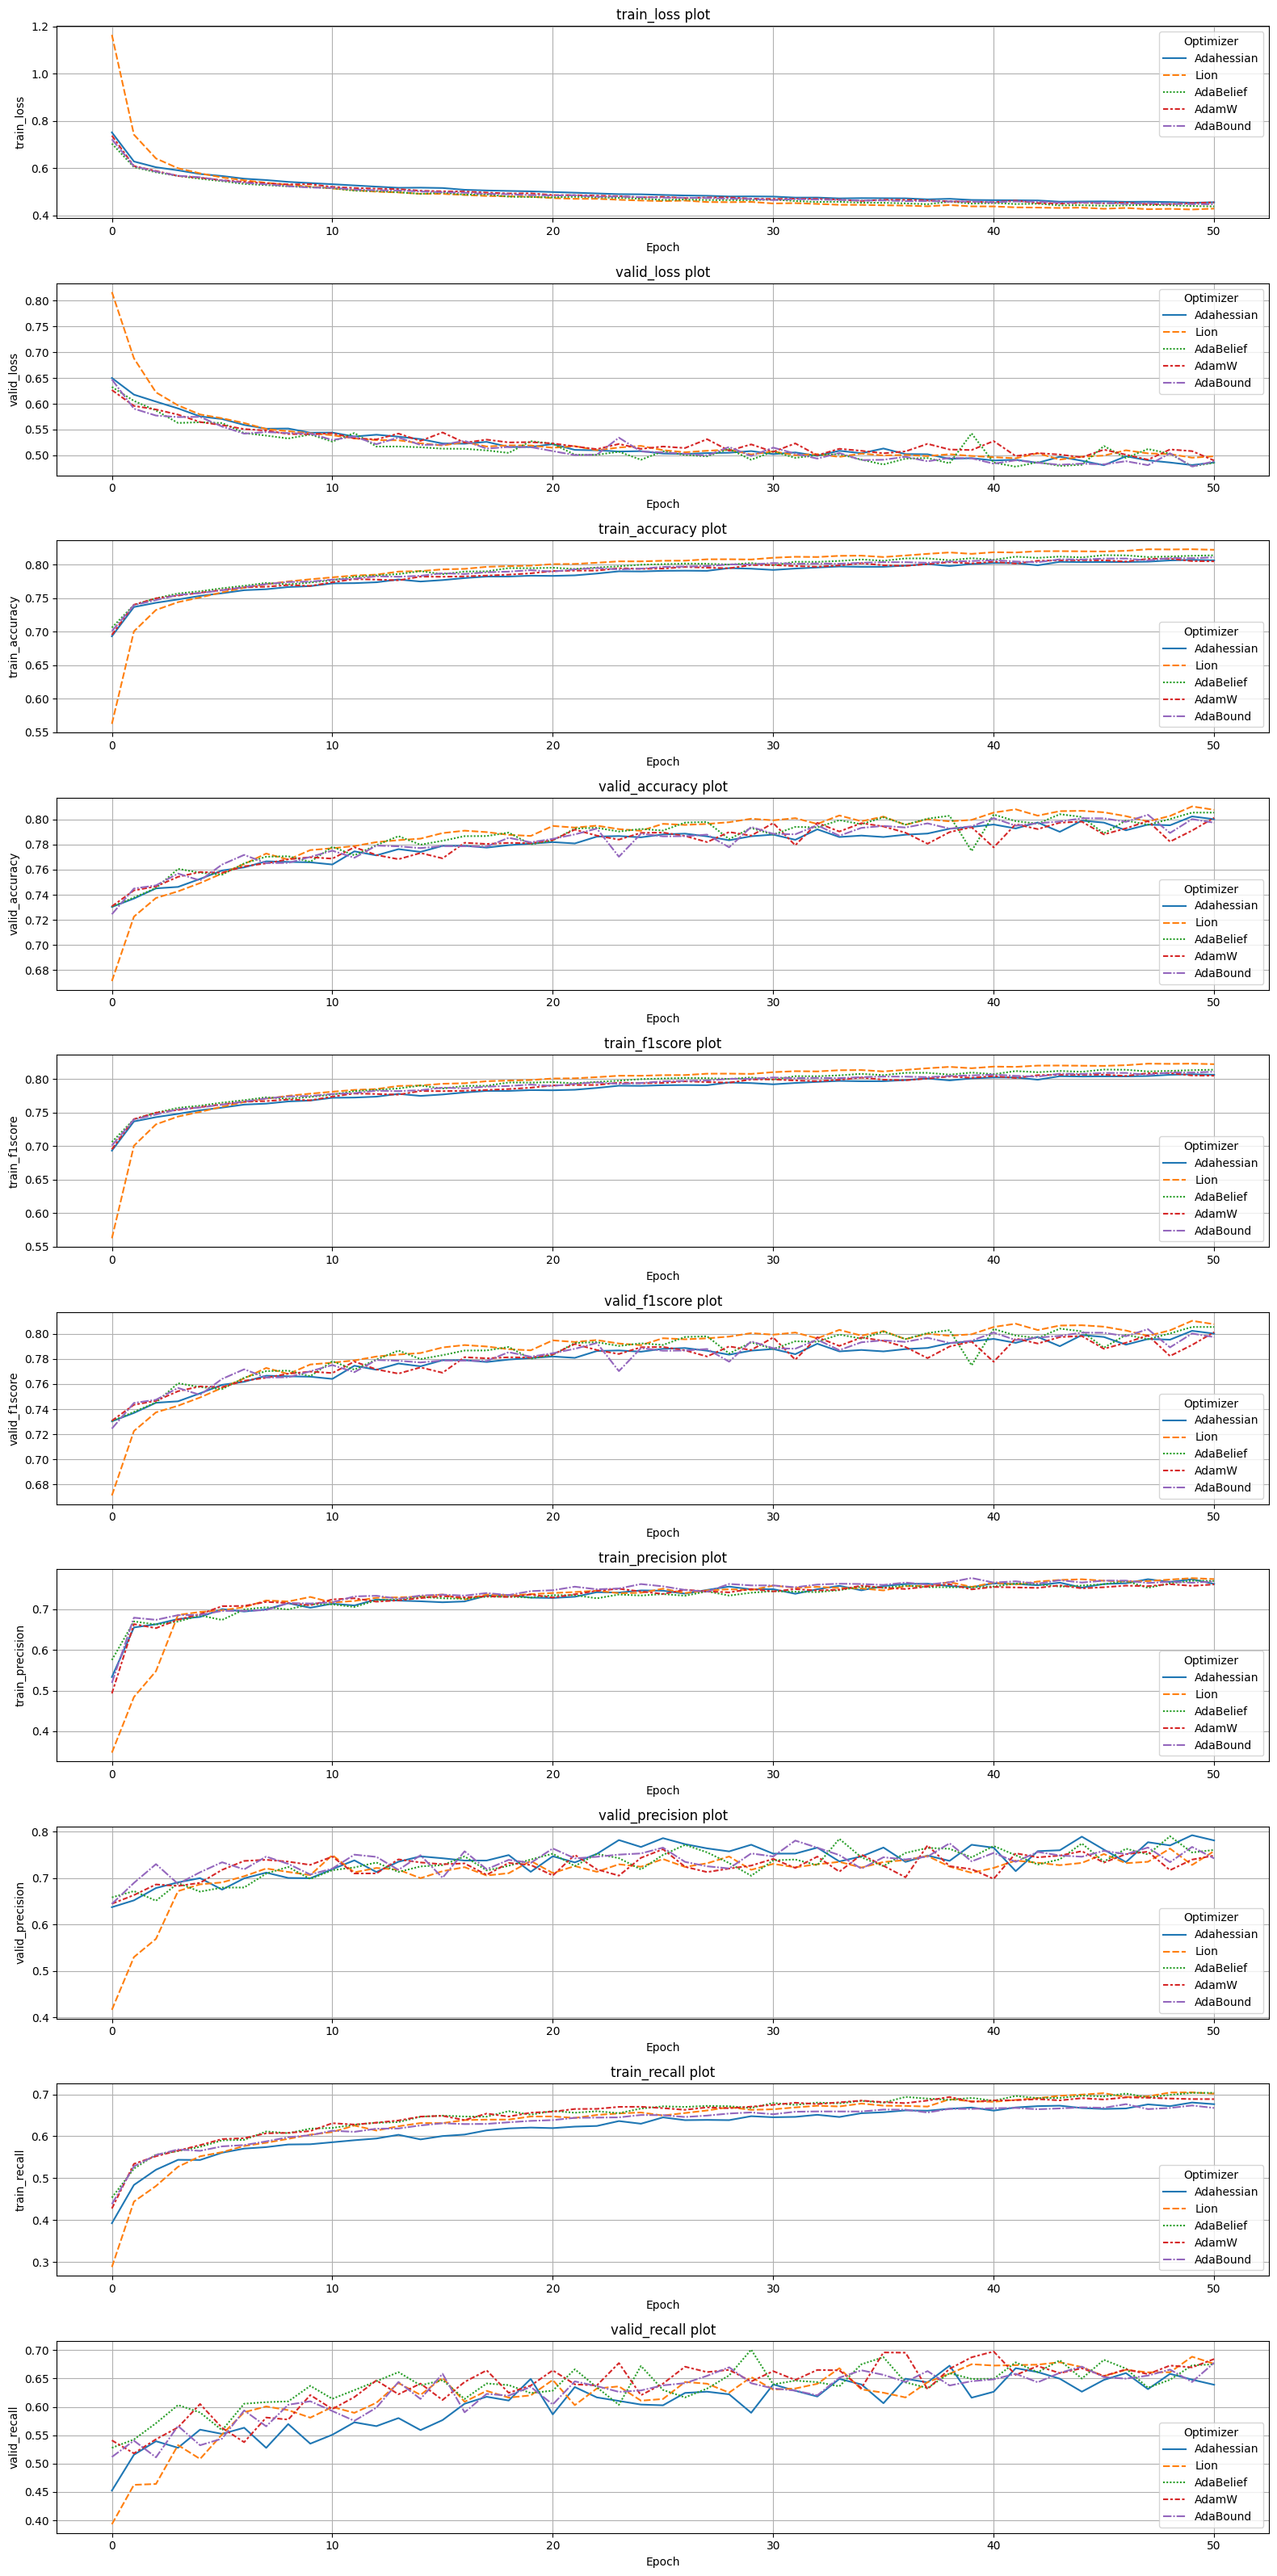

In [18]:
exclude_metrics = ["train_confusion_matrix", "valid_confusion_matrix", "train_multiclass_roc", "valid_multiclass_roc", "time_training"]
plot_results(results, exclude_metrics=exclude_metrics, test_num_epochs=TEST_NUM_EPOCHS, epoch_step=TEST_EPOCH_STEP)

**Анализ графиков:**

Lion начинает довольно с высоких loss на первых эпохах, затем показывает быструю сходимость, кривая обучения гладкая. Можем видеть достаточно сильные колебания на valid_loss для AdamW, для остальных оптимизаторов в меньшей мере.  
На train_f1score, valid_f1score по прежнему AdamW и AdamBound остаются шумными, Lion снова показывает хорошую сходимость.  
Достаточно плохой сходимостью и сильной зашемленностью обладает Adahessian на valid_recall, на первых 10-15 эпохах нет существенного прироста. Вид кривых для остальных оптимизаторов примерно совпадает.  

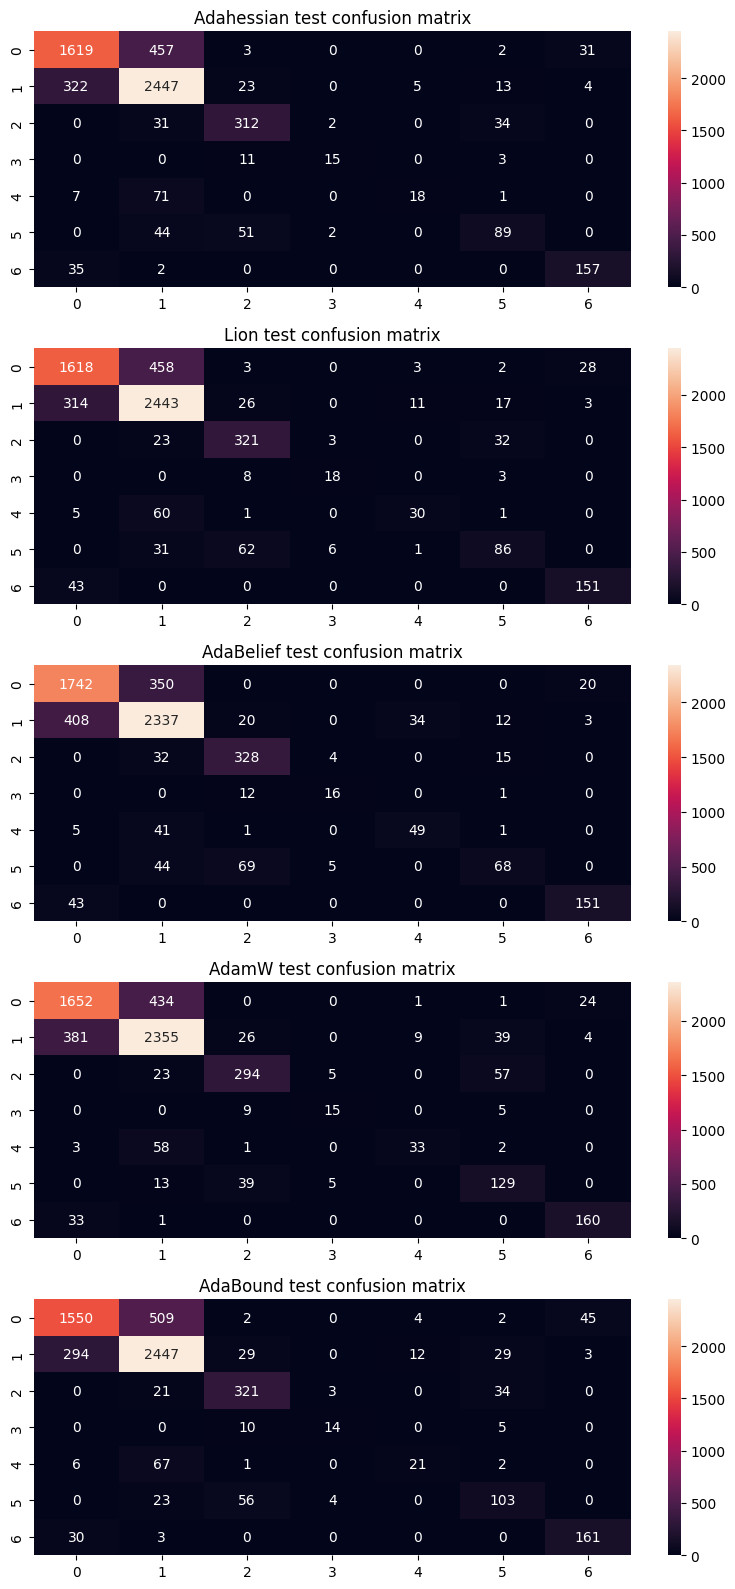

In [19]:
plot_confusion_matrices_results(results)

Мало представленные объекты достаточно точно, по сравнению с остальными, классифицировала модель, обученная на AdamW (для 5-6 классов) и AdaBelief (для 4 класса)

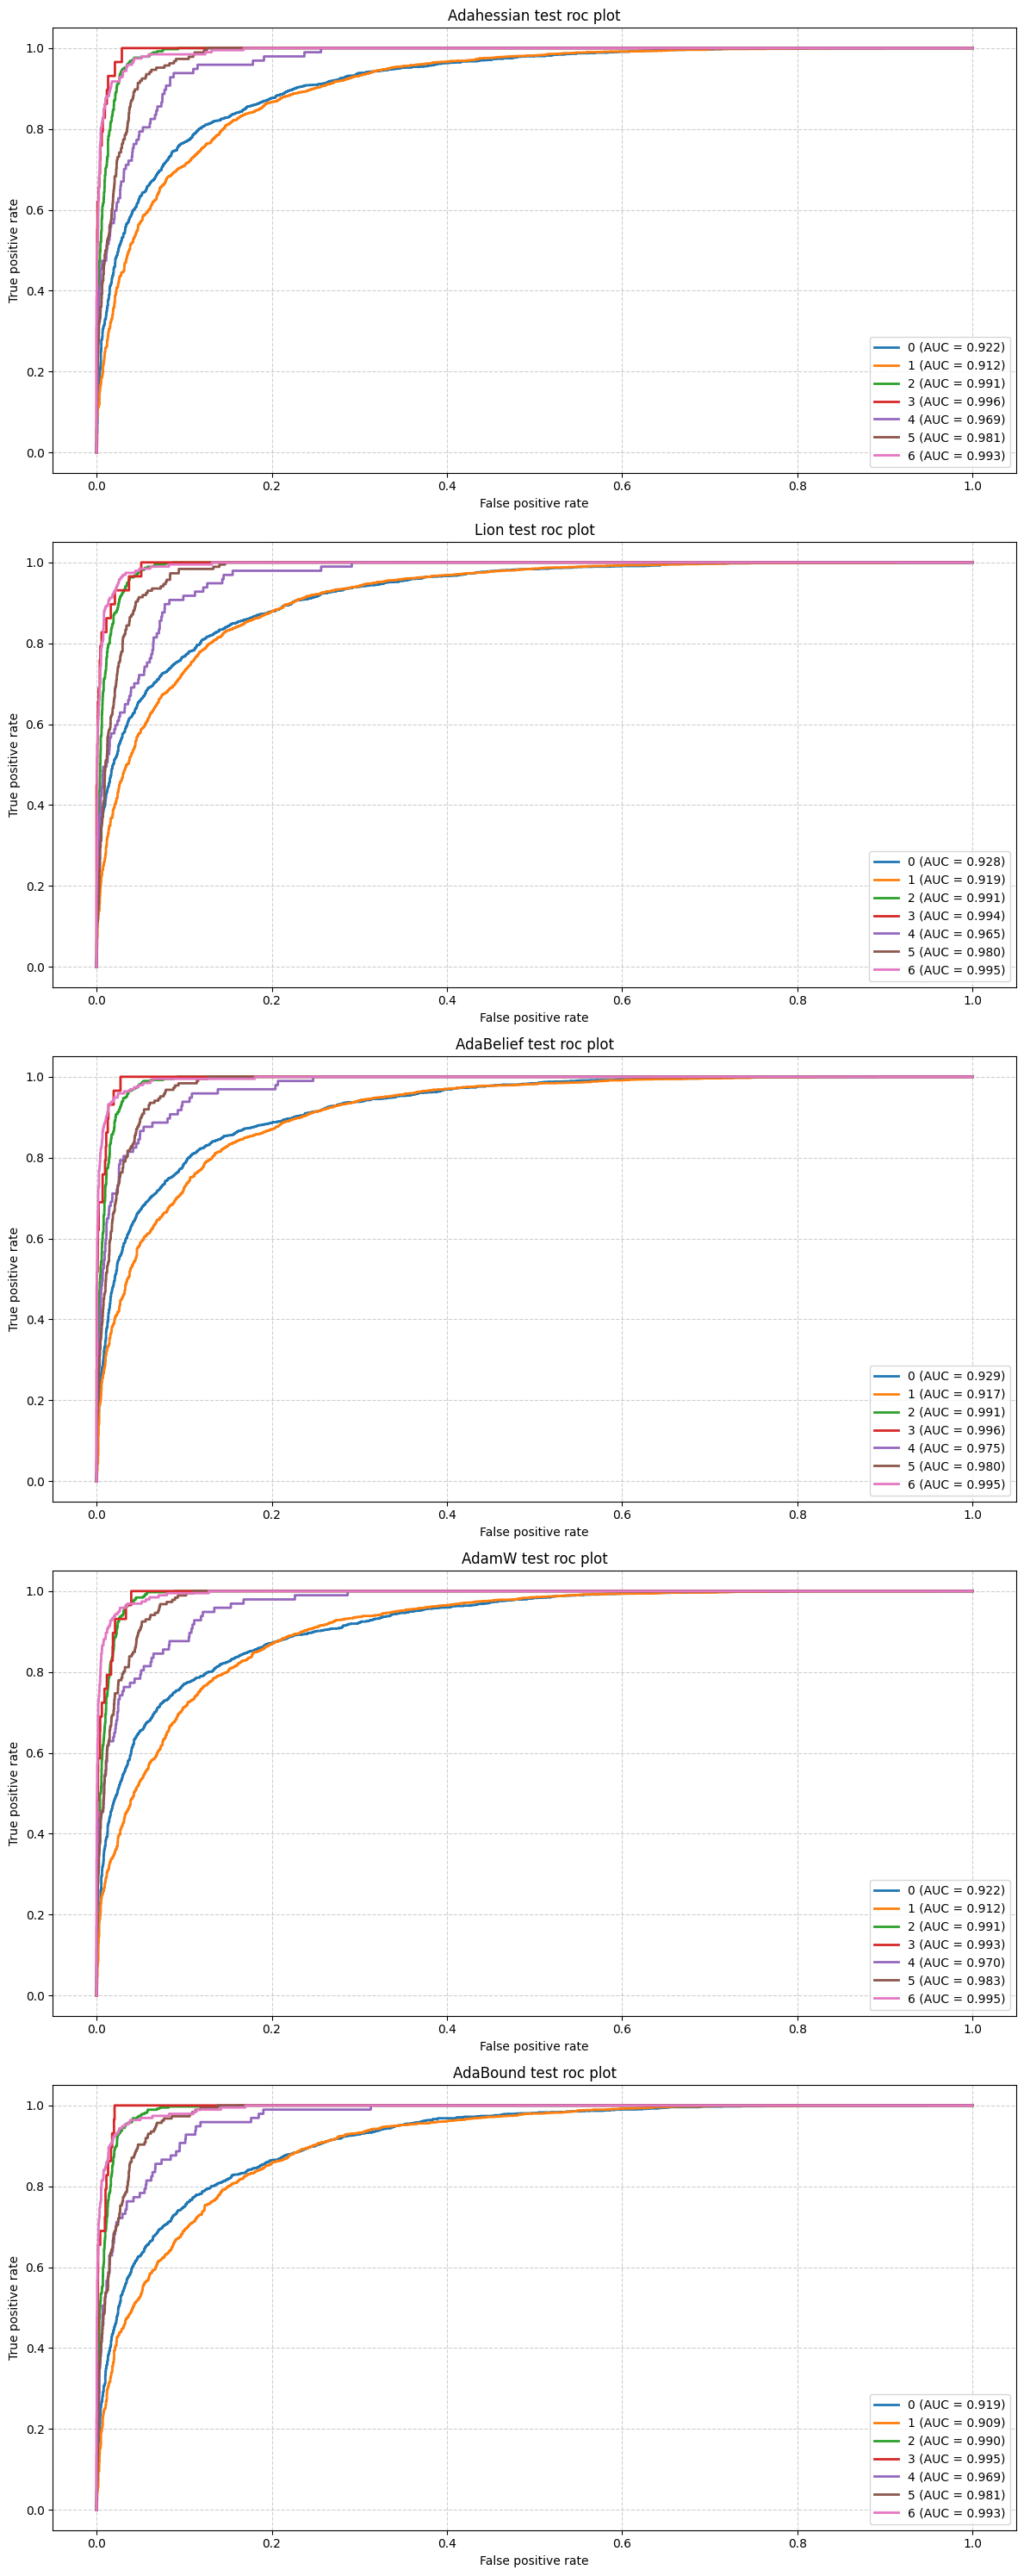

In [21]:
test_plot_roc_results(results, num_classes=num_classes)

Вид roc-кривых достаточно схож для всех оптимизаторов, Lion показывает наибольшее auc значение.